##HIDING FUTURE WORDS WITH CAUSAL ATTENTION

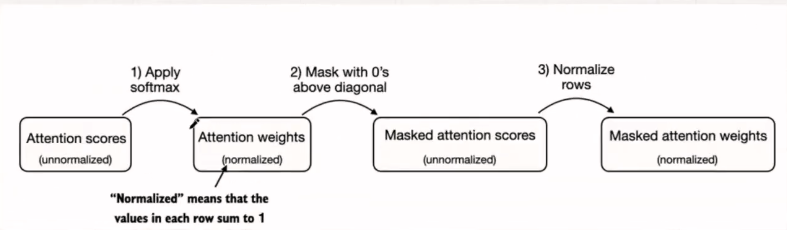

In the **first step**, we compute the attention weights using the softmax function as we have done in Simplified Attention Mechanism with Trainable Weights:

In [ ]:
import torch

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

In [ ]:
import torch.nn as nn

class SelfAttention_v2(nn.Module):

    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)

        context_vec = attn_weights @ values
        return context_vec

In [ ]:
torch.manual_seed(789)
d_in = inputs.shape[1]
d_out = 2
sa_v2 = SelfAttention_v2(d_in, d_out)

In [ ]:
queries = sa_v2.W_query(inputs) #A
keys = sa_v2.W_key(inputs)
values = sa_v2.W_value(inputs)
attn_scores = queries @ keys.T
attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=1)
print(attn_weights)

tensor([[0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
        [0.2041, 0.1659, 0.1662, 0.1496, 0.1665, 0.1477],
        [0.2036, 0.1659, 0.1662, 0.1498, 0.1664, 0.1480],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.1661, 0.1564],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.1585],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


We can now use PyTorch's tril function to create a mask where the values above the diagonal are zero:

In [ ]:
context_length = attn_scores.shape[0]
mask_simple = torch.tril(torch.ones(context_length, context_length))
print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


Now, we can multiply this mask with the attention weights to zero out the values above the diagonal:

In [ ]:
masked_simple = attn_weights*mask_simple
print(masked_simple)

tensor([[0.1921, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2041, 0.1659, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2036, 0.1659, 0.1662, 0.0000, 0.0000, 0.0000],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.0000, 0.0000],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<MulBackward0>)


As we can see, the elements above the diagonal are successfully zeroed out

The third step is to renormalize the attention weights to sum up to 1 again in each row.

We can achieve this by dividing each element in each row by the sum in each row:

In [ ]:
row_sums = masked_simple.sum(dim=1, keepdim=True)
masked_simple_norm = masked_simple / row_sums
print(masked_simple_norm)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<DivBackward0>)


The main purpose of causal attention is to not have any influence of the future tokens. However, when we applied softmax to the attention scores we got attention weight matrix. While doing so, all the entries had influence from later token/entries. So this leads to a **data leakage** problem.

While we could be technically done with implementing causal attention at this point, we can
take advantage of a mathematical property of the softmax function.

We can implement the computation of the masked attention weights more efficiently in fewer steps.

In [ ]:
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)
print(masked)

tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_fn=<MaskedFillBackward0>)


The softmax function converts its inputs into a probability distribution.

When negative infinity values (-∞) are present in a row, the softmax function treats them as zero probability.

(Mathematically, this is because e -∞ approaches 0.)

We can implement this more efficient masking "trick" by creating a mask with 1's above the diagonal and then replacing these 1's with negative infinity (-inf) values:

Now, all we need to do is apply the softmax function to these masked results, and we are done.

In [ ]:
mod_attn_weights = torch.softmax(masked / keys.shape[-1]**0.5, dim=1)
print(mod_attn_weights)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


As we can see based on the output, the values in each row sum to 1, and no further normalization is necessary.

Masking in Transformers sets scores for future tokens to a large negative value, making their influence in the softmax calculation effectively zero.

The softmax function then recalculates attention weights only among the unmasked tokens.

This process ensures no information leakage from masked tokens, focusing the model solely on the intended data.

We could now use the modified attention weights to compute the context vectors via context_vec = attn_weights @ values.

However, in the next section, we first cover another minor tweak to the causal attention mechanism that is useful for reducing overfitting when training LLMs.

In [ ]:
mod_context_vec = mod_attn_weights @ values
print(mod_context_vec)

tensor([[-0.0872,  0.0286],
        [-0.0991,  0.0501],
        [-0.0999,  0.0633],
        [-0.0983,  0.0489],
        [-0.0514,  0.1098],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


###MASKING ADDITIONAL ATTENTION WEIGHTS WITH DROPOUT

In the following code example, we use a dropout rate of 50%, which means masking out half of the attention weights.

When we train the GPT model in later chapters, we will use a lower dropout rate, such as 0.1 or 0.2.

In [ ]:
torch.manual_seed(123)
dropout = torch.nn.Dropout(0.5) #A
example = torch.ones(6, 6) #B
print(dropout(example))

tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])


When applying dropout to an attention weight matrix with a rate of 50%, half of the elements in the matrix are randomly set to zero.

To compensate for the reduction in active elements, the values of the remaining elements in the matrix are scaled up by a factor of 1/0.5 =2.

This scaling is crucial to maintain the overall balance of the attention weights, ensuring that the average influence of the attention mechanism remains consistent during both the training and inference phases.

**Now, let's apply dropout to the attention weight matrix itself:**

In [ ]:
torch.manual_seed(123)
print(dropout(mod_attn_weights))

tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.7599, 0.6194, 0.6206, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.4921, 0.4925, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3966, 0.0000, 0.3775, 0.0000, 0.0000],
        [0.0000, 0.3327, 0.3331, 0.3084, 0.3331, 0.0000]],
       grad_fn=<MulBackward0>)


As we can see above, the resulting attention weight matrix now has additional elements zeroed out and the remaining ones rescaled.

Having gained an understanding of causal attention and dropout masking, we will develop a concise Python class in the following section.

This class is designed to facilitate the efficient application of these two techniques.

###IMPLEMENTING A COMPACT CAUSAL ATTENTION CLASS

Before we begin, one more thing is to ensure that the code can handle batches consisting of more than one input.

This will ensure that the CausalAttention class supports the batch outputs produced by the data loader we implemented earlier.

For simplicity, to simulate such batch inputs, we duplicate the input text example:

2 inputs with 6 tokens each, and each token has embedding dimension 3

In [ ]:
batch = torch.stack((inputs, inputs), dim=0)
print(batch.shape)

torch.Size([2, 6, 3])


This results in a 3D tensor consisting of 2 input texts with 6 tokens each, where each token is a 3-dimensional embedding vector.

The following CausalAttention class is similar to the SelfAttention class we implemented earlier, except that we now added the dropout and causal mask components as highlighted in the following code.

Step 1: Compared to the previous SelfAttention_v1 class, we added a dropout layer.

Step 2: The register_buffer call is also a new addition (more information is provided in the following text).

Step 3: We transpose dimensions 1 and 2, keeping the batch dimension at the first position (0).

Step 4: In PyTorch, operations with a trailing underscore are performed in-place, avoiding unnecessary memory copies

In [ ]:
class CausalAttention(nn.Module):

    def __init__(self, d_in, d_out, context_length,
                 dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout) # New
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1)) # New

    def forward(self, x):
        b, num_tokens, d_in = x.shape # New batch dimension b
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        attn_scores = queries @ keys.transpose(1, 2) # Changed transpose
        attn_scores.masked_fill_(  # New, _ ops are in-place
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)  # `:num_tokens` to account for cases where the number of tokens in the batch is smaller than the supported context_size
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )
        attn_weights = self.dropout(attn_weights) # New

        context_vec = attn_weights @ values
        return context_vec

We can use the CausalAttention class as follows:

In [ ]:
torch.manual_seed(123)
context_length = batch.shape[1]
ca = CausalAttention(d_in, d_out, context_length, 0.0)
context_vecs = ca(batch)
print("context_vecs.shape:", context_vecs.shape)

context_vecs.shape: torch.Size([2, 6, 2])


In [ ]:
print(context_vecs)

tensor([[[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]],

        [[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]]], grad_fn=<UnsafeViewBackward0>)


As we can see, the resulting context vector is a 3D tensor where each token is now represented by a 2D embedding:

###EXTENDING SINGLE HEAD ATTENTION TO MULTI-HEAD ATTENTION

In practical terms, implementing multi-head attention involves creating multiple instances of the self-attention mechanism, each with its own weights, and then combining their outputs

In code, we can achieve this by implementing a simple MultiHeadAttentionWrapper class that stacks multiple instances of our previously implemented CausalAttention module:

In [ ]:
class MultiHeadAttentionWrapper(nn.Module):

    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        self.heads = nn.ModuleList(
            [CausalAttention(d_in, d_out, context_length, dropout, qkv_bias)
             for _ in range(num_heads)]
        )

    def forward(self, x):
        return torch.cat([head(x) for head in self.heads], dim=-1) #dim = -1 as we are concatenating along the columns

For example, if we use this MultiHeadAttentionWrapper class with two attention heads (via num_heads=2) and CausalAttention output dimension d_out=2, this results in a 4- dimensional context vectors (d_out*num_heads=4)

To illustrate further with a concrete example, we can use the MultiHeadAttentionWrapper class similar to the CausalAttention class before:

In [ ]:
torch.manual_seed(123)
context_length = batch.shape[1] # This is the number of tokens
d_in, d_out = 3, 2
mh_attn = MultiHeadAttentionWrapper(d_in, d_out, context_length, 0.0, num_heads=2)
context_vecs = mh_attn(batch)
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)
context_vecs.shape: torch.Size([2, 6, 4])


The first dimension of the resulting context_vecs tensor is 2 since we have two input texts (the input texts are duplicated, which is why the context vectors are exactly the same for those).

The second dimension refers to the 6 tokens in each input. The third dimension refers to the 4-dimensional embedding of each token.

In this section, we implemented a MultiHeadAttentionWrapper that combined multiple single-head attention modules.
However, note that these are processed sequentially via [head(x) for head in self.heads] in the forward method.

We can improve this implementation by processing the heads in parallel.

One way to achieve this is by computing the outputs for all attention heads simultaneously via matrix multiplication, as we will explore in the next section.

###IMPLEMENTING MULTI-HEAD ATTENTION WITH WEIGHT SPLITS

Instead of maintaining two separate classes, MultiHeadAttentionWrapper and CausalAttention, we can combine both of these concepts into a single MultiHeadAttention class.

Also, in addition to just merging the MultiHeadAttentionWrapper with the CausalAttention code, we will make some other modifications to implement multi-head attention more efficiently.

In the MultiHeadAttentionWrapper, multiple heads are implemented by creating a list of CausalAttention objects (self.heads), each representing a separate attention head.

The CausalAttention class independently performs the attention mechanism, and the results from each head are concatenated.

In contrast, the following MultiHeadAttention class integrates the multi-head functionality within a single class.

It splits the input into multiple heads by reshaping the projected query, key, and value tensors and then combines the results from these heads after computing attention.

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x) # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec) # optional projection

        return context_vec

To understand it, let us take a simple example:

Step 1: Start with the input

        b, num_tokens, d-in = (1,3,6)

what it does:

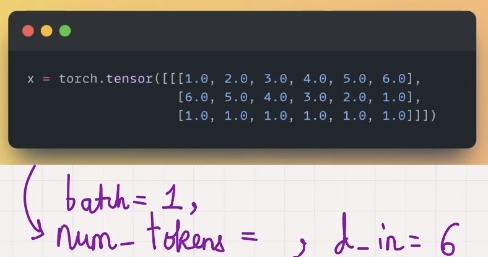

Step 2: Decide d-out, num_heads

d-out must be same as d-in. so, d-out = 6

each head will have a dimension, head_dim = (d-out)/(number of heads)

Step 3: Initialize trainable weight matrices for key, query, value (Wk, Wq, Wv).

Their dimension needs to be d_in*d_out

Step 4: Calculate Keys, Quesries, Value Matrix

Keys = Input * Wk

Query = Input * Wq

Value = Input * Wv

each having a shape of (batch_size, number of tokens, d_out)

Step 5: Unroll last dimension of Keys, Queries and Values to include the number of heads (num_heads) and head-dimensions (head_dim)

head_dim = d_out/num_heads

Now the shape of matrices needs to be changed

from (batch_size, number of tokens, d_out) to (batch_size, num_tokens, num_heads, head_dim)

Step 6: Group matrices by "number of heads"

meaning, the shape of matrices needs to be changed

from (b, num_tokens, num_heads, head_dim) to (b, num_heads, num_tokens, head_dim)

Thus the tensors are grouped by head!!

Step 7: Find the Attention Scores

Attention_Scores = Queries * Keys.Transpose(2,3)

and here the dimensions of the output = (b, num_heads, num_tokens, num_tokens)

Step 8: Find attention weights

Mask attention scores to implement causal attention

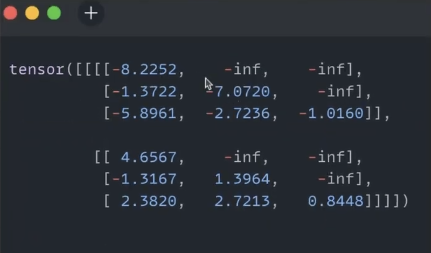

before applying softmax, always divide by sqrt(head_dim), this is useful for back_propagation and leads to stable gradient.

Then after applying softmax:

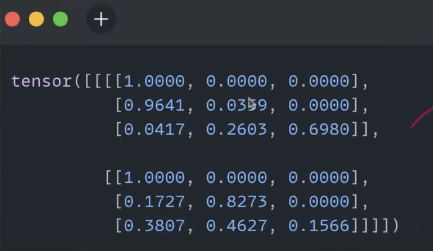

Step 9: Computing Context Vector

Context_Vector_Matrix = Attention_weights * Values

here, dimensions are (b, num_heads, num_tokens, num_tokens) and (b, num_heads, num_tokens, num_tokens) respectively. So these tensors are able to be multiplied!

Step 10: Reformat Context Vectors:



the shape of the context vector needs to be changed

from (b, num_heads, num_tokens, head_dim) to (b, num_tokens, num_heads, head_dim)

transpose of 1st index and the 2nd index.

Step 11: Combine heads/Flatten each token output into each row

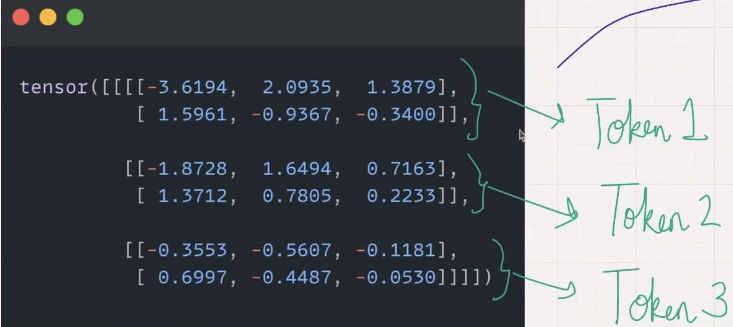

this needs to be flattened and the result looks like:

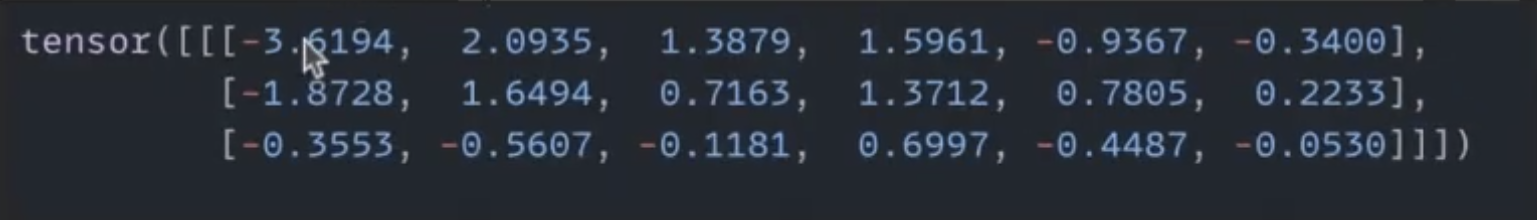

dimension of the final output becomes: (b, num_tokens, d_out)

Using the MultiHeadAttention Class on a tensor

In [ ]:
torch.manual_seed(123)

# Define the tensor with 3 rows and 6 columns
inputs = torch.tensor(
    [[0.43, 0.15, 0.89, 0.55, 0.87, 0.66],  # Row 1
     [0.57, 0.85, 0.64, 0.22, 0.58, 0.33],  # Row 2
     [0.77, 0.25, 0.10, 0.05, 0.80, 0.55]]  # Row 3
)

batch = torch.stack((inputs, inputs), dim=0)
print(batch.shape)

batch_size, context_length, d_in = batch.shape
d_out = 6
mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads=2)
context_vecs = mha(batch)
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

torch.Size([2, 3, 6])
tensor([[[ 0.1569, -0.0873,  0.0210,  0.0215, -0.3243, -0.2518],
         [ 0.1117, -0.0547,  0.0406, -0.0213, -0.3251, -0.2993],
         [ 0.1196, -0.0491,  0.0318, -0.0635, -0.2788, -0.2578]],

        [[ 0.1569, -0.0873,  0.0210,  0.0215, -0.3243, -0.2518],
         [ 0.1117, -0.0547,  0.0406, -0.0213, -0.3251, -0.2993],
         [ 0.1196, -0.0491,  0.0318, -0.0635, -0.2788, -0.2578]]],
       grad_fn=<ViewBackward0>)
context_vecs.shape: torch.Size([2, 3, 6])


As we can see based on the results, the output dimension is directly controlled by the d_out argument:

In this section, we implemented the MultiHeadAttention class that we will use in the upcoming sections when implementing and training the LLM itself.

Note that while the code is fully functional, we used relatively small embedding sizes and numbers of attention heads to keep the outputs readable.

For comparison, the smallest GPT-2 model (117 million parameters) has 12 attention heads and a context vector embedding size of 768.

The largest GPT-2 model (1.5 billion parameters) has 25 attention heads and a context vector embedding size of 1600.

Note that the embedding sizes of the token inputs and context embeddings are the same in GPT models (d_in = d_out).